Import library

In [1]:
import os
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

In [2]:
os.chdir('../src')
os.getcwd()

'c:\\Users\\user\\Documents\\Projects\\6. Computer Vision\\Code\\computer-vision-playground\\src'

In [3]:
import opencv_utils

%load_ext autoreload
%autoreload 2

In [4]:
os.chdir('..')
os.getcwd()

'c:\\Users\\user\\Documents\\Projects\\6. Computer Vision\\Code\\computer-vision-playground'

# 1. Thresholding-Based Image Segmentation

Segmentation procedures are usually done using two approaches – 
- Detecting discontinuity in images and linking edges to form the region (known as edge-based segmenting)
- Detecting similarity among pixels based on intensity levels (known as threshold-based segmenting)

## Global Thresholding

### Simple Thresholding

- Select an initial estimate of the threshold T.
- Segment the image using T to form two groups G1 and G2: G1 consists of all pixels with intensity values > T, and G2 consists of all pixels - with intensity values ≤ T. 
- Compute the average intensity values m1 and m2 for groups G1 and G2.σ
- Compute the new value of the threshold T as T = (m1 + m2)/2
- Repeat steps 2 through 4 until the difference in the subsequent value of T is smaller than a pre-defined value δ.
- Segment the image as g(x,y) = 1 if f(x,y) > T and g(x,y) = 0 if f(x,y) ≤ T. 

This algorithm works well for images that have a clear valley in their histogram. The larger the value of δ, the smaller will be the number of iterations. The initial estimate of T can be made equal to the average pixel intensity of the entire image.

Different methods to use simple thresholding-

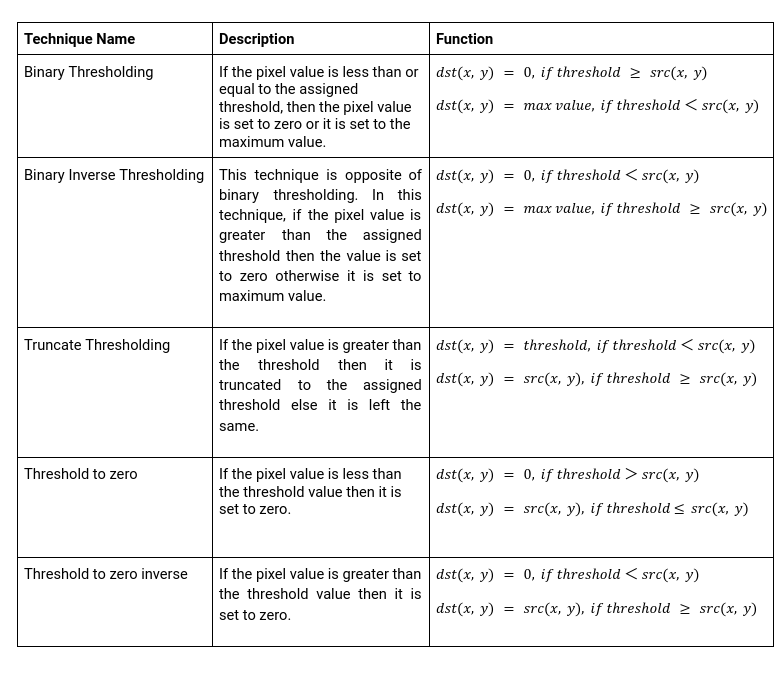

In [5]:
## Load image
img = opencv_utils.read_image("./data/raw/bird.jpg", cv.IMREAD_GRAYSCALE)

# Arguments of function cv2.threshold
# cv2.threshold(grayscaled image, threshold value, maximum value of pixel, type of threshold)
# Output is a tuple containg the threshold value and thresholded image

## Binary Thresholding

t, thresh_img = cv.threshold(img,70,255,cv.THRESH_BINARY)


## Binary Inverse Thresholding

t,thresh1_img = cv.threshold(img,70,255,cv.THRESH_BINARY_INV)

## Truncate Thresholding
rect,thresh2_img = cv.threshold(img,70,255,cv.THRESH_TRUNC)

## Threshold to zero
rect,thresh3_img = cv.threshold(img,70,255,cv.THRESH_TOZERO)

## Threshold to zero inverse
rect,thresh4_img = cv.threshold(img,127,255,cv.THRESH_TOZERO_INV)


The above simple global thresholding can be made optimum by using Otsu’s method. Otsu’s method is optimum in the sense that it maximizes the between-class variance.

### Otsu's thresholding

Since we are working with bimodal images, Otsu's algorithm tries to find a threshold value (t) which minimizes the weighted within-class variance given by the relation:

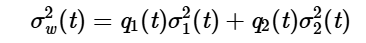

where,

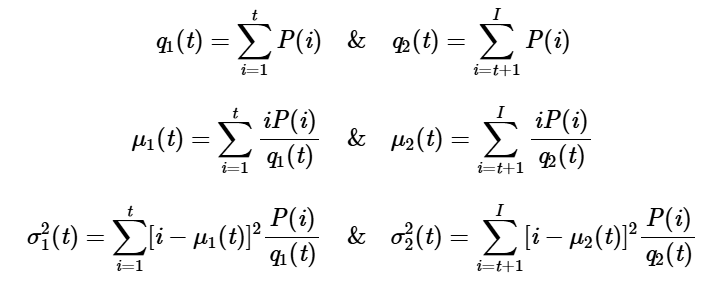

It actually finds a value of t which lies in between two peaks such that variances to both classes are minimal. It can be simply implemented in Python as follows:

Numpy implementation

In [6]:
blur = cv.GaussianBlur(img,(5,5),0)
 
# find normalized_histogram, and its cumulative distribution function
hist = cv.calcHist([blur],[0],None,[256],[0,256])
hist_norm = hist.ravel()/hist.sum()
Q = hist_norm.cumsum()
 
bins = np.arange(256)
 
fn_min = np.inf
thresh = -1
 
for i in range(1,256):
    p1,p2 = np.hsplit(hist_norm,[i]) # probabilities
    q1,q2 = Q[i],Q[255]-Q[i] # cum sum of classes
    if q1 < 1.e-6 or q2 < 1.e-6:
        continue
    b1,b2 = np.hsplit(bins,[i]) # weights
 
    # finding means and variances
    m1,m2 = np.sum(p1*b1)/q1, np.sum(p2*b2)/q2
    v1,v2 = np.sum(((b1-m1)**2)*p1)/q1,np.sum(((b2-m2)**2)*p2)/q2
 
    # calculates the minimization function
    fn = v1*q1 + v2*q2
    if fn < fn_min:
        fn_min = fn
        thresh = i

In [7]:
thresh

101

Numpy implemetation

In [8]:
blur = cv.GaussianBlur(img,(5,5),0) #Applying Gaussian Blurr on image to get better threshold

t,thresh5_img = cv.threshold(blur,128,255,cv.THRESH_BINARY+cv.THRESH_OTSU)

In [9]:
t

101.0

## Local Thresholding

### Variable Thresholding

There are broadly two different approaches to local thresholding. One approach is to partition the image into non-overlapping rectangles. Then the techniques of global thresholding or Otsu’s method are applied to each of the sub-images. Hence in the image partitioning technique, the methods of global thresholding are applied to each sub-image rectangle by assuming that each such rectangle is a separate image in itself. This approach is justified when the sub-image histogram properties are suitable (have two peaks with a wide valley in between) for the application of thresholding techniques but the entire image histogram is corrupted by noise and hence is not ideal for global thresholding.

The other approach is to compute a variable threshold at each point from the neighborhood pixel properties. Let us say that we have a neighborhood Sxy of a pixel having coordinates (x,y). If the mean and standard deviation of pixel intensities in this neighborhood be mxy and σxy , then the threshold at each point can be computed as:

$$
T_{xy} = a\sigma_{xy} + b m_{xy}
$$

where a and b are arbitrary constants. The above definition of the variable threshold is just an example. Other definitions can also be used according to the need. 

The segmented image is computed as:

$$
g(x, y) = 
\begin{cases} 
1 & \text{if } f(x, y) > T_{xy} \\
0 & \text{if } f(x, y) \le T_{xy}
\end{cases}
$$

Moving averages can also be used as thresholds. This technique of image thresholding is the most general one and can be applied to widely different cases. 

### Adaptive thresholding

Adaptive thresholding is a local thresholding technique. This technique considers each pixel and its neighborhood. The arithmetic mean or Gaussian mean of pixels intensity is commonly used to calculate the threshold of the neighborhood; then the threshold value is used to classify the pixel. In Gaussian mean, pixel value farther from the center of the region contributes less in finding the threshold of the region, while in arithmetic mean, all pixel values contribute equally. 

In addition to the parameters described above, the method cv.adaptiveThreshold takes three input parameters:

The adaptiveMethod decides how the threshold value is calculated:

- cv.ADAPTIVE_THRESH_MEAN_C: The threshold value is the mean of the neighbourhood area minus the constant C.
- cv.ADAPTIVE_THRESH_GAUSSIAN_C: The threshold value is a gaussian-weighted sum of the neighbourhood values minus the constant C.

The blockSize determines the size of the neighbourhood area and C is a constant that is subtracted from the mean or weighted sum of the neighbourhood pixels.

In [10]:
# Arithmatic Mean Adaptive thresholding
thresh6_img = cv.adaptiveThreshold(img,255,cv.ADAPTIVE_THRESH_MEAN_C,cv.THRESH_BINARY,5,4)

# Gaussian Mean Thresholding
thresh7_img = cv.adaptiveThreshold(img,255,cv.ADAPTIVE_THRESH_GAUSSIAN_C,cv.THRESH_BINARY,5,4)

## Visualization

C:\Users\user\AppData\Local\Temp\ipykernel_23528\1060494403.py:17: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


<Figure size 1200x800 with 0 Axes>

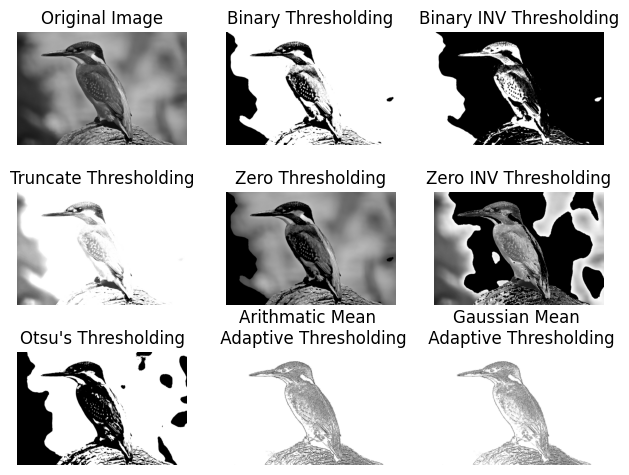

In [11]:
# Prepare titles and images for plotting
titles = ['Original Image', 'Binary Thresholding', 'Binary INV Thresholding',
          'Truncate Thresholding', 'Zero Thresholding', 'Zero INV Thresholding', "Otsu's Thresholding", "Arithmatic Mean \n Adaptive Thresholding", "Gaussian Mean \n Adaptive Thresholding"]
images = [img, thresh_img, thresh1_img, thresh2_img, thresh3_img, thresh4_img, thresh5_img, thresh6_img, thresh7_img]

# Plotting
plt.figure(figsize=(12, 8))
fig, axes = plt.subplots((len(titles)+2)//3, 3)

for i in range(len(titles)):
    
    axes[i//3, i%3].imshow(images[i], cmap='gray')
    axes[i//3, i%3].set_title(titles[i])
    axes[i//3, i%3].axis('off')

fig.tight_layout()
fig.show()

## Introduction to UNet: Deep learning Model for Image Segmentation

The UNet architecture was introduced for BioMedical Image segmentation by Olag Ronneberger et al. With this U-Net architecture, the segmentation of images can be computed with a modern GPU within small amounts of time. UNet uses the concept of a Fully Convolution Network along with little modification. This model helps to localize the object in an image and find the mask of that object.

The image below shows the architecture of U-Net. 

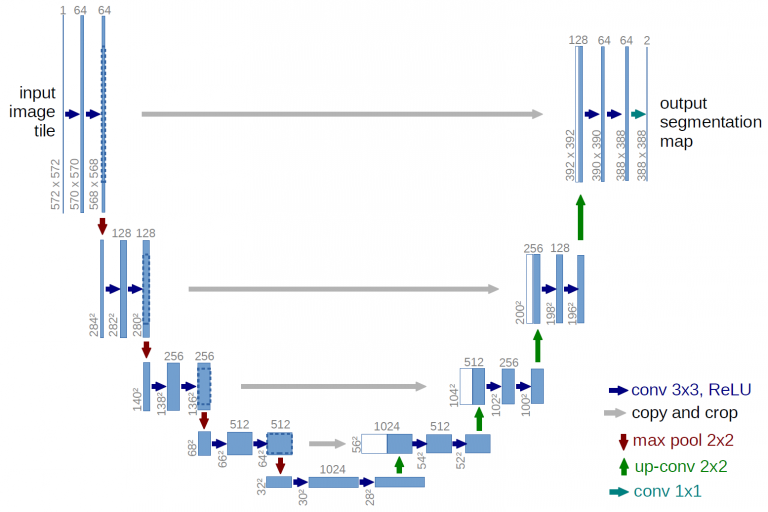

U-shaped architecture

- This model got its name from the U-shaped architecture.
- As we can see in the image, this architecture has two paths created as an encoder-decoder network.
- We apply two convolution layers and max pooling layers in the left path.
- The ReLU activation function follows each convolution.
- On the right path, we apply transpose convolutions along with two regular convolutions

# 2. Morphological Transformations

## Morphological Transformations

While non-linear filters are often used to enhance grayscale and color images, they are also used extensively to process binary images. Such images often occur after a thresholding operation. The most common binary image operations are called morphological operations, because they change the shape of the underlying binary objects. Some of the well known Morphological Transformations are: Opening, Closing, Dilation, Erosion, Majority.

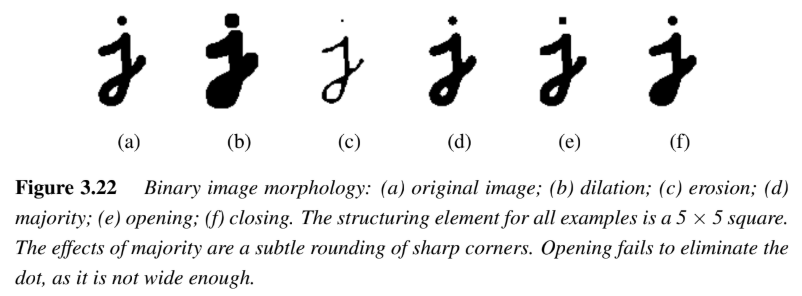

Figure 3.22 shows examples:

- Dilation thickens the shapes.

- Erosion thins the shapes.

- Opening removes tiny objects.

- Closing fills tiny holes.

| Operation   | Math                                      | Meaning                                                                 |
|-------------|-------------------------------------------|-------------------------------------------------------------------------|
| Dilation    | `dilate(f, s) = θ(c, 1)`                 | Set output to 1 if at least 1 pixel under structuring element is 1. It grows objects. |
| Erosion     | `erode(f, s) = θ(c, S)`                  | Set output to 1 if all pixels under structuring element are 1. It shrinks objects. |
| Majority    | `maj(f, s) = θ(c, S/2)`                  | Set output to 1 if more than half the pixels are 1.                     |
| Opening     | `open(f, s) = dilate(erode(f, s), s)`    | First shrink then grow → removes small objects.                         |
| Closing     | `close(f, s) = erode(dilate(f, s), s)`   | First grow then shrink → fills small holes.                             |

### Erosion

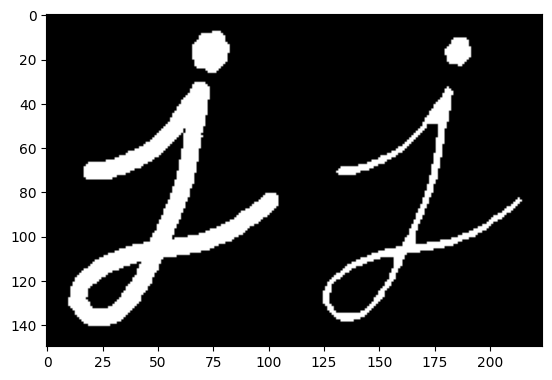

In [34]:
img = opencv_utils.read_image("./data/raw/j.png", cv.IMREAD_GRAYSCALE)

kernel = np.ones((5,5),np.uint8)
erosion = cv.erode(img,kernel,iterations = 1)

plt.imshow(np.hstack([img, erosion]), cmap='gray')
plt.show()

### Dialation

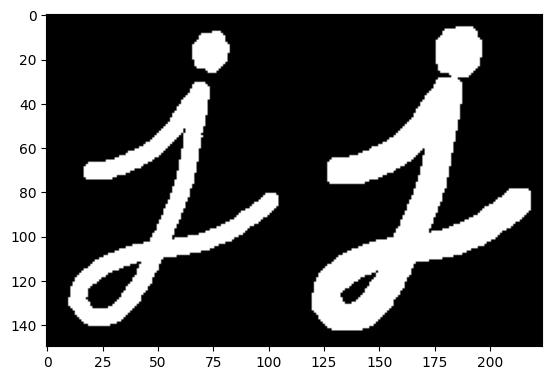

In [33]:
img = opencv_utils.read_image("./data/raw/j.png", cv.IMREAD_GRAYSCALE)

kernel = np.ones((5,5),np.uint8)
dilation = cv.dilate(img,kernel,iterations = 1)

plt.imshow(np.hstack([img, dilation]), cmap='gray')
plt.show()

### Opening

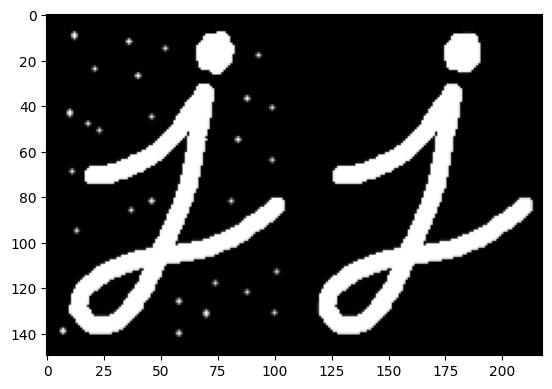

In [28]:
img = opencv_utils.read_image("./data/raw/opening.png", cv.IMREAD_GRAYSCALE)

kernel = np.ones((5,5),np.uint8)
opening = cv.morphologyEx(img, cv.MORPH_OPEN, kernel)

plt.imshow(np.hstack([img, opening]), cmap='gray')
plt.show()

### Closing

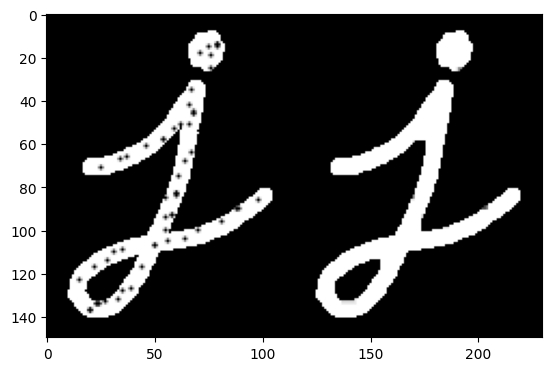

In [ ]:
img = opencv_utils.read_image("./data/raw/closing.png", cv.IMREAD_GRAYSCALE)

kernel = np.ones((5,5),np.uint8)
closing = cv.morphologyEx(img, cv.MORPH_CLOSE, kernel)

plt.imshow(np.hstack([img, closing]), cmap='gray')
plt.show()

### Morphological Gradient
It is the difference between dilation and erosion of an image.

The result will look like the outline of the object.

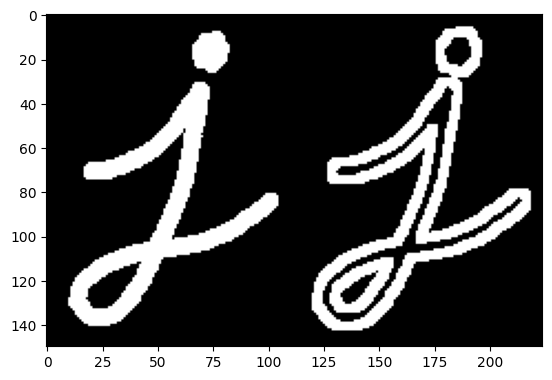

In [30]:
img = opencv_utils.read_image("./data/raw/j.png", cv.IMREAD_GRAYSCALE)

kernel = np.ones((5,5),np.uint8)
gradient = cv.morphologyEx(img, cv.MORPH_GRADIENT, kernel)

plt.imshow(np.hstack([img, gradient]), cmap='gray')
plt.show()

### Top Hat
It is the difference between input image and Opening of the image.

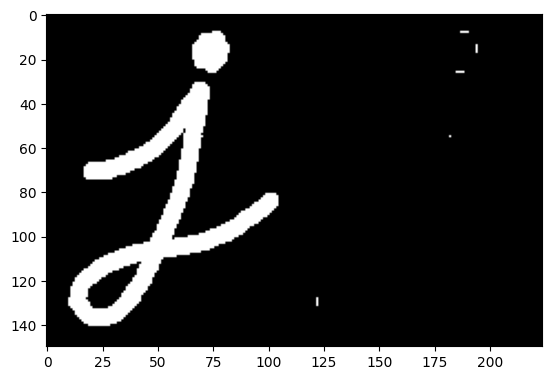

In [31]:
img = opencv_utils.read_image("./data/raw/j.png", cv.IMREAD_GRAYSCALE)

kernel = np.ones((5,5),np.uint8)
tophat = cv.morphologyEx(img, cv.MORPH_TOPHAT, kernel)

plt.imshow(np.hstack([img, tophat]), cmap='gray')
plt.show()

### Black Hat
It is the difference between the closing of the input image and input image.

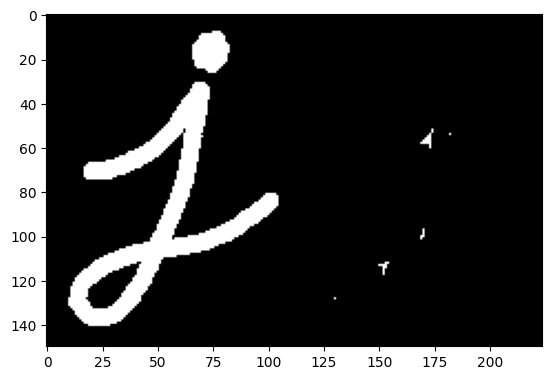

In [32]:
img = opencv_utils.read_image("./data/raw/j.png", cv.IMREAD_GRAYSCALE)

kernel = np.ones((5,5),np.uint8)
blackhat = cv.morphologyEx(img, cv.MORPH_BLACKHAT, kernel)

plt.imshow(np.hstack([img, blackhat]), cmap='gray')
plt.show()

### Structuring Element
We manually created a structuring elements in the previous examples with help of Numpy. It is rectangular shape. But in some cases, you may need elliptical/circular shaped kernels. So for this purpose, OpenCV has a function, cv.getStructuringElement(). You just pass the shape and size of the kernel, you get the desired kernel.

In [48]:
# Rectangular Kernel
cv.getStructuringElement(cv.MORPH_RECT,(5,5))

array([[1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1]], dtype=uint8)

In [49]:
# Elliptical Kernel
cv.getStructuringElement(cv.MORPH_ELLIPSE,(5,5))

array([[0, 0, 1, 0, 0],
       [1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1],
       [0, 0, 1, 0, 0]], dtype=uint8)

In [50]:
# Cross-shaped Kernel
cv.getStructuringElement(cv.MORPH_CROSS,(5,5))

array([[0, 0, 1, 0, 0],
       [0, 0, 1, 0, 0],
       [1, 1, 1, 1, 1],
       [0, 0, 1, 0, 0],
       [0, 0, 1, 0, 0]], dtype=uint8)

# 3. Edge Detection

#### Convolution vs Cross Correlation
A convolution is an integral that expresses the amount of overlap of one function as it is shifted over
another function. We can think of the convolution as a filtering operation.
The Correlation calculates a similarity measure for two input signals (e.g., two image patches). The
output of correlation reaches a maximum when the two signals match best. Correlation can be though
of as a measure of relatedness of two signals.


## Designing a Good Edge Detector
An optimal edge detector must have certain qualities:
1. Good detection
    - It must minimize the probability of detecting false positives (which are spurious edges,
generally caused by noise) and false negatives (missing real edges, which can be caused
by smoothing, among other things). If it detects something as an edge, it should be an
edge.
2. Good localization
    - The detected edges must be as close as possible to the actual edges in the original image.
The detector must identify where the edges occur and pinpoint the exact location of the
edge; it must also be consistent in determining which pixels are involved in each edge.
3. Silent response
    - It must minimize the number of local maxima around the true edge (returning one point
only for each true edge point). It should tell you that there is one very specific edge
instead of splitting one edge into multiple detected edges. In other words, only the real
border of the edge is captured; other possibilities are suppressed.

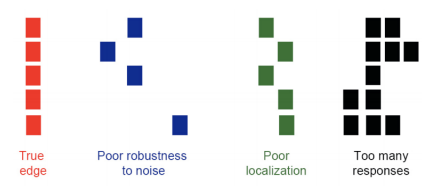

Fig: Sample problems of bad edge detectors

## Simple Edge Detectors
1.  Characterizing Edges
Characterizing edges (i.e., characterizing them properly so they can be recognized) is an important
first step in detecting edges. For our purposes, we will define an edge as a rapid place of change in
the image intensity function. If we plot the intensity function along the horizontal scanline, we see
that the edges correspond to the extra of the derivative. Therefore, noticing sharp changes along this
plot will likely give us edges.

2. Image Gradient
The gradient of an image has been defined as the following:

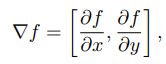,

while its direction has been defined as:

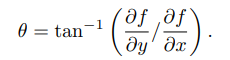

Fig: The gradient vector directions

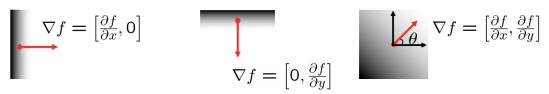


3. Effects of Noise
If there is excessive noise in an image, the partial derivatives will not be effective for identifying the
edges.

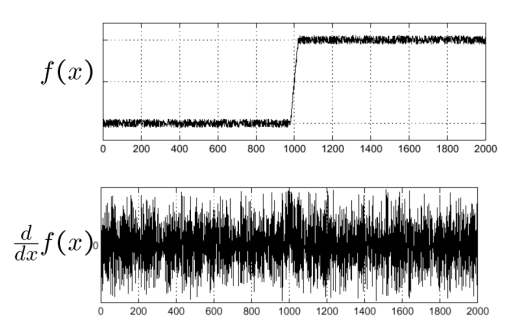

Fig: The derivative of an edge in a noisy image

In order to account for the noise, the images must first be smoothed. This is a process in which
pixel values are recalculated so that they more closely resemble their neighbors. The smoothing is
achieved by means of convolving the image with a filter (e.g., gaussian kernel).

There are, of course, some concerns to keep in mind when smoothing an image. The image smoothing
does remove noise, but it also blurs the edges; the use of large filters can result in the loss of edges
and the finer details of the image.

Gaussian blur- The Gaussian blur is the result of blurring an image by a Gaussian function to reduce image noise. It
is a low-pass filter, meaning it attenuates high frequency signals. You will generally use Gaussian
blurring as a preliminary step.


## Edge Detection

### Edge Basics
There are four possible sources of edges in an image:
- Surface normal discontinuity (surface changes
direction sharply)
- Depth discontinuity (one surface behind another)
- Surface color discontinuity
(single surface changes color)
- Illumination discontinuity (shadows/lighting).

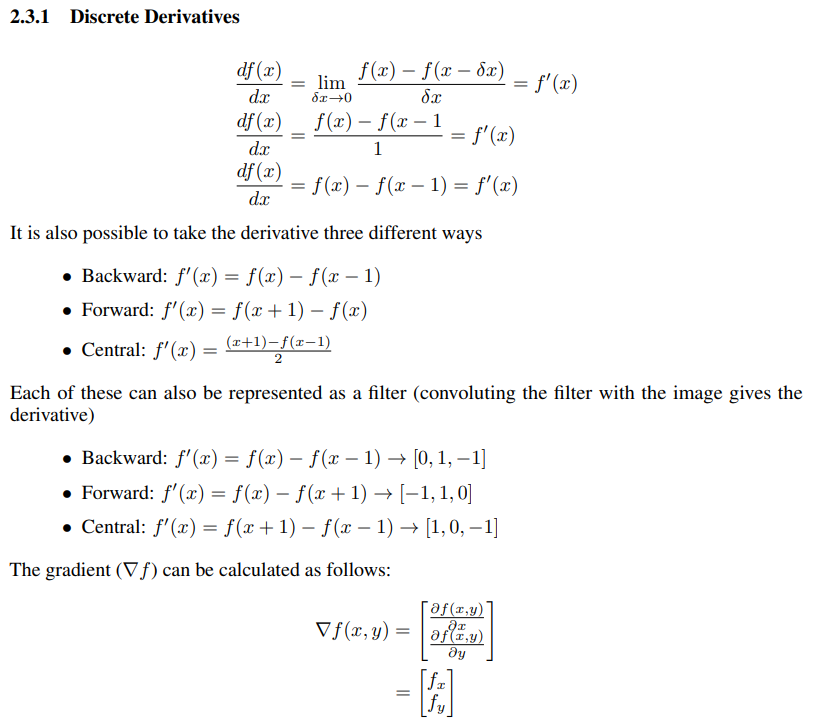

###  i. Sobel Noise Detector
This algorithm utilizes 2 3 × 3 kernels which, once convolved with the image, approximate the x and
y derivatives of the original image.

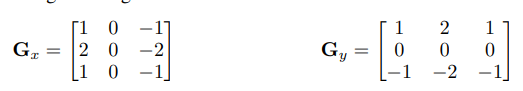

These matrices represent the result of smoothing and differentiation

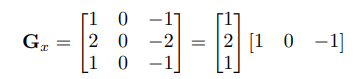

The Sobel Filter has many problems, including poor localization. The Sobel Filter also favors horizontal and vertical edges over oblique edges

### ii. Canny Edge Detector
The Canny Edge Detector has five algorithmic steps:
- Suppress noise
- Compute gradient magnitude and direction
- Apply non-maximum suppression
- Hysteresis thresholding
- Connectivity analysis to detect edges

a.  Suppress noise
    
We can both suppress noise and compute the derivatives in the x and y directions using a method similar to the Sobel filter.

b. Compute gradient magnitude and direction

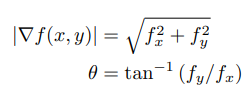



# 4. Fourier Transform

Theory
Fourier Transform is used to analyze the frequency characteristics of various filters. For images, 2D Discrete Fourier Transform (DFT) is used to find the frequency domain. A fast algorithm called Fast Fourier Transform (FFT) is used for calculation of DFT. Details about these can be found in any image processing or signal processing textbooks. Please see Additional Resources_ section.

For a sinusoidal signal, , we can say  is the frequency of signal, and if its frequency domain is taken, we can see a spike at . If signal is sampled to form a discrete signal, we get the same frequency domain, but is periodic in the range 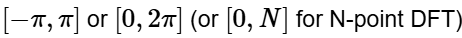. You can consider an image as a signal which is sampled in two directions. So taking fourier transform in both X and Y directions gives you the frequency representation of image.

More intuitively, for the sinusoidal signal, if the amplitude varies so fast in short time, you can say it is a high frequency signal. If it varies slowly, it is a low frequency signal. You can extend the same idea to images. Where does the amplitude varies drastically in images ? At the edge points, or noises. So we can say, edges and noises are high frequency contents in an image. If there is no much changes in amplitude, it is a low frequency component. 

## Fourier Transform in Numpy
First we will see how to find Fourier Transform using Numpy. Numpy has an FFT package to do this. np.fft.fft2() provides us the frequency transform which will be a complex array. Its first argument is the input image, which is grayscale. Second argument is optional which decides the size of output array. If it is greater than size of input image, input image is padded with zeros before calculation of FFT. If it is less than input image, input image will be cropped. If no arguments passed, Output array size will be same as input.

Now once you got the result, zero frequency component (DC component) will be at top left corner. If you want to bring it to center, you need to shift the result by  in both the directions. This is simply done by the function, np.fft.fftshift(). (It is more easier to analyze). Once you found the frequency transform, you can find the magnitude spectrum.

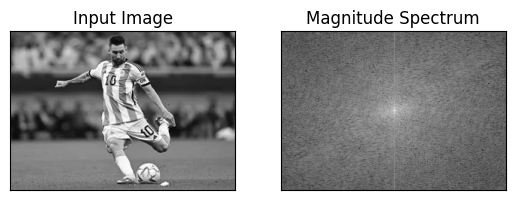

In [9]:
img = opencv_utils.read_image("./data/raw/messi.webp", cv.IMREAD_GRAYSCALE)

f = np.fft.fft2(img)
fshift = np.fft.fftshift(f)
magnitude_spectrum = 20*np.log(np.abs(fshift))

plt.subplot(121),plt.imshow(img, cmap = 'gray')
plt.title('Input Image'), plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(magnitude_spectrum, cmap = 'gray')
plt.title('Magnitude Spectrum'), plt.xticks([]), plt.yticks([])
plt.show()

So you found the frequency transform. Now you can do some operations in frequency domain, like high pass filtering and reconstruct the image, ie find inverse DFT. For that you simply remove the low frequencies by masking with a rectangular window of size 60x60. Then apply the inverse shift using np.fft.ifftshift() so that DC component again come at the top-left corner. Then find inverse FFT using np.ifft2() function. The result, again, will be a complex number. You can take its absolute value.

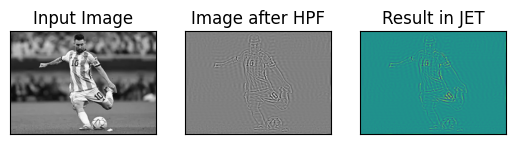

In [11]:
rows, cols = img.shape
crow, ccol = rows//2, cols//2
fshift[crow-30:crow+31, ccol-30:ccol+31] = 0
f_ishift = np.fft.ifftshift(fshift)
img_back = np.fft.ifft2(f_ishift)
img_back = np.real(img_back)
 
plt.subplot(131),plt.imshow(img, cmap = 'gray')
plt.title('Input Image'), plt.xticks([]), plt.yticks([])
plt.subplot(132),plt.imshow(img_back, cmap = 'gray')
plt.title('Image after HPF'), plt.xticks([]), plt.yticks([])
plt.subplot(133),plt.imshow(img_back)
plt.title('Result in JET'), plt.xticks([]), plt.yticks([])
 
plt.show()

## Fourier Transform in OpenCV
OpenCV provides the functions cv.dft() and cv.idft() for this. It returns the same result as previous, but with two channels. First channel will have the real part of the result and second channel will have the imaginary part of the result. The input image should be converted to np.float32 first. 

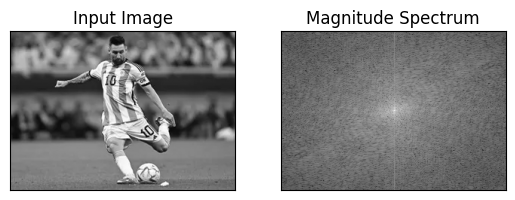

In [15]:
img = opencv_utils.read_image("./data/raw/messi.webp", cv.IMREAD_GRAYSCALE)

dft = cv.dft(np.float32(img),flags = cv.DFT_COMPLEX_OUTPUT)
dft_shift = np.fft.fftshift(dft)

magnitude_spectrum = 20*np.log(cv.magnitude(dft_shift[:,:,0],dft_shift[:,:,1]))

plt.subplot(121),plt.imshow(img, cmap = 'gray')
plt.title('Input Image'), plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(magnitude_spectrum, cmap = 'gray')
plt.title('Magnitude Spectrum'), plt.xticks([]), plt.yticks([])
plt.show()

So, now we have to do inverse DFT. In previous session, we created a HPF, this time we will see how to remove high frequency contents in the image, ie we apply LPF to image. It actually blurs the image. For this, we create a mask first with high value (1) at low frequencies, ie we pass the LF content, and 0 at HF region.

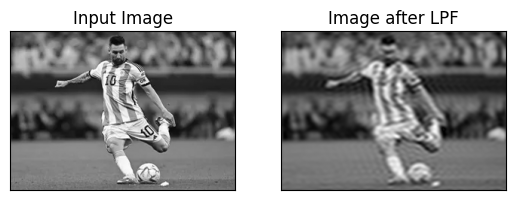

In [21]:
rows, cols = img.shape
crow, ccol = rows//2, cols//2

# create a mask first, center square is 1, remaining all zeros
mask = np.zeros((rows,cols,2),np.uint8)
mask[crow-30:crow+30, ccol-30:ccol+30] = 1

# apply mask and inverse DFT
fshift = dft_shift*mask
f_ishift = np.fft.ifftshift(fshift)
img_back = cv.idft(f_ishift)
img_back = cv.magnitude(img_back[:,:,0],img_back[:,:,1])

plt.subplot(121),plt.imshow(img, cmap = 'gray')
plt.title('Input Image'), plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(img_back, cmap = 'gray')
plt.title('Image after LPF'), plt.xticks([]), plt.yticks([])
plt.show()

## Performance Optimization of DFT
Performance of DFT calculation is better for some array size. It is fastest when array size is power of two. The arrays whose size is a product of 2’s, 3’s, and 5’s are also processed quite efficiently. So if you are worried about the performance of your code, you can modify the size of the array to any optimal size (by padding zeros) before finding DFT. For OpenCV, you have to manually pad zeros. But for Numpy, you specify the new size of FFT calculation, and it will automatically pad zeros for you.

So how do we find this optimal size ? OpenCV provides a function, cv.getOptimalDFTSize() for this. It is applicable to both cv.dft() and np.fft.fft2().

In [23]:
img = opencv_utils.read_image("./data/raw/messi.webp", cv.IMREAD_GRAYSCALE)

rows,cols = img.shape
print("{} {}".format(rows,cols))

211 300


In [24]:
nrows = cv.getOptimalDFTSize(rows)
ncols = cv.getOptimalDFTSize(cols)
print("{} {}".format(nrows,ncols))

216 300


In [26]:
cols

300

In [27]:
nimg = np.zeros((nrows,ncols))
nimg[:rows,:cols] = img

In [28]:
%timeit fft1 = np.fft.fft2(img)

5.92 ms ± 176 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [29]:
%timeit fft2 = np.fft.fft2(img,[nrows,ncols])

2.34 ms ± 576 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [30]:
%timeit dft1= cv.dft(np.float32(img),flags=cv.DFT_COMPLEX_OUTPUT)

807 μs ± 132 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [31]:
%timeit dft2= cv.dft(np.float32(nimg),flags=cv.DFT_COMPLEX_OUTPUT)

468 μs ± 12 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


## Why Laplacian is a High Pass Filter?
A similar question was asked in a forum. The question is, why Laplacian is a high pass filter? Why Sobel is a HPF? etc. And the first answer given to it was in terms of Fourier Transform. Just take the fourier transform of Laplacian for some higher size of FFT.

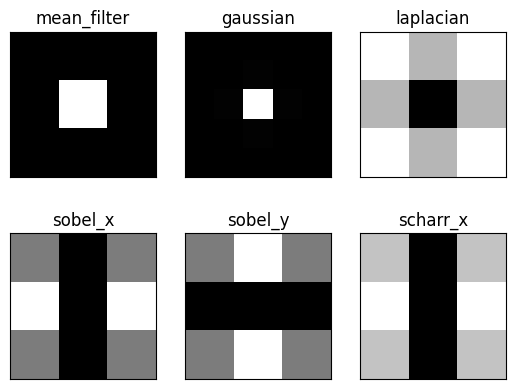

In [32]:
# simple averaging filter without scaling parameter
mean_filter = np.ones((3,3))

# creating a gaussian filter
x = cv.getGaussianKernel(5,10)
gaussian = x*x.T

# different edge detecting filters
# scharr in x-direction
scharr = np.array([[-3, 0, 3],
                   [-10,0,10],
                   [-3, 0, 3]])
# sobel in x direction
sobel_x= np.array([[-1, 0, 1],
                   [-2, 0, 2],
                   [-1, 0, 1]])
# sobel in y direction
sobel_y= np.array([[-1,-2,-1],
                   [0, 0, 0],
                   [1, 2, 1]])
# laplacian
laplacian=np.array([[0, 1, 0],
                    [1,-4, 1],
                    [0, 1, 0]])

filters = [mean_filter, gaussian, laplacian, sobel_x, sobel_y, scharr]
filter_name = ['mean_filter', 'gaussian','laplacian', 'sobel_x', \
                'sobel_y', 'scharr_x']
fft_filters = [np.fft.fft2(x) for x in filters]
fft_shift = [np.fft.fftshift(y) for y in fft_filters]
mag_spectrum = [np.log(np.abs(z)+1) for z in fft_shift]

for i in range(6):
    plt.subplot(2,3,i+1),plt.imshow(mag_spectrum[i],cmap = 'gray')
    plt.title(filter_name[i]), plt.xticks([]), plt.yticks([])

plt.show()